# Import

In [ ]:
import datetime as dt
from datetime import datetime, timedelta

import dask

import numpy as np
from numpy.random import uniform, randint

from pathlib import Path
import geopandas as gpd
import pandas as pd

import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib.animation as animation
import cmocean

import xarray as xr
from xhistogram.xarray import histogram as xhist
from glob import glob
import cartopy
import cartopy.crs as ccrs
from cartopy.crs import Geodetic, PlateCarree
from time import time
import warnings
import shapely
import itertools

warnings.simplefilter("ignore")

# Set Parameters

In [3]:
# # zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Fucus_BSH_20210101-20210129_dt60min_N43600_seed123.zarr")
# zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2022/Fucus_BSH_20220101-20220625_dt60min_N453440_seed123.zarr")
# ds_trajectories = xr.open_zarr(zarr_path)#.compute()
# ds_trajectories.nbytes/1e9

In [ ]:
# Parameters
base_path = "/gxfs_work/geomar/smomw597/2025_Fucus"
release_depth = 0
relative_particle_speed = 1

In [ ]:
base_path = Path(base_path)
repo_path = base_path

In [ ]:
zarr_path = Path(repo_path,"output/Trajectories")
zarr_files = sorted(zarr_path.glob(f"20??/Fucus_BSH_*_d{release_depth}_s{relative_particle_speed}_*.zarr"))
print(np.array(zarr_files))
ds_trajectories = xr.concat([xr.open_zarr(s) for s in zarr_files], dim="trajectory")
ds_trajectories.nbytes/1e9

In [23]:
ds_trajectories = ds_trajectories.assign(trajectory=np.arange(len(ds_trajectories.trajectory)))

In [24]:
if len(np.unique(ds_trajectories.isel(obs=0).z.compute())) > 1:
        ds_traj = ds_trajectories.isel(obs=0).groupby("z")
        ds_trajectories = ds_trajectories.sel(trajectory=ds_traj[0].trajectory.values)
        # ds_trajectories = ds_trajectories.sel(trajectory=ds_traj[1].trajectory.values)
else:
        ds_trajectories = ds_trajectories.drop("z")
ds_trajectories.nbytes/1e9

220.20562496

In [25]:
try: ds_trajectories = ds_trajectories.rename(dict(CellID="cell_ID"))
except: ""
list_cell_ID = ds_trajectories.cell_ID.isel(obs=0).astype(int)

In [ ]:
n_obs = len(ds_trajectories.obs)

In [ ]:
try: 
        ds_trajectories.lat.isel(trajectory=0).compute()
        ds_trajectories = ds_trajectories.isel(obs=slice(n_obs))
except: ds_trajectories = ds_trajectories.isel(obs=slice(2112))

In [ ]:
release_area_path = Path(repo_path, "data/Fucus_location_shp")
gdf_release_area = gpd.read_file(Path(release_area_path, "REDLIST_SIS_Macrophytes.geojson"))
gdf_release_area = gdf_release_area.loc[
        gdf_release_area.F_vesiculo != 0,
        ["geometry", "CELLCODE", "F_vesiculo", "CELLID"]
]
release_centroid = gpd.GeoDataFrame(gdf_release_area.CELLCODE, geometry=gdf_release_area.geometry.centroid)

In [ ]:
subbasins_path = Path(repo_path, "data/HELCOM_subbasins_2022_level2")
gdf_subbasins_area = gpd.read_file(Path(subbasins_path, "HELCOM_subbasins_2022_level2.shp"))

gdf_subbasins_area = gdf_subbasins_area.to_crs(crs=Geodetic()).rename(dict(level_2="subbasin"), axis=1)

In [13]:
gdf_release_centroids = gpd.sjoin_nearest(
        left_df=release_centroid, 
        right_df=gdf_subbasins_area, 
        how="left", 
)[["CELLCODE", "subbasin", "geometry"]]

In [ ]:
earth_radius = 6371
degrees_to_radians = np.pi / 180
radians_to_degrees = 180 / np.pi

def dlat_to_dkm(dlat):
        return dlat * earth_radius * degrees_to_radians
def dlon_to_dkm(latitude, dlon):
        r = earth_radius * np.cos(np.multiply(latitude, degrees_to_radians))
        return dlon * r * degrees_to_radians
def latlon_dist_to_km(ds):
        dlat = ds.lat - ds.lat.isel(obs=0, drop=True)
        return ((dlat_to_dkm(dlat)**2 + dlon_to_dkm(ds.lat + dlat/2, ds.lon - ds.lon.isel(obs=0, drop=True))**2)**.5).rename("dist")

In [28]:
ds_trajectories = ds_trajectories.assign(
        dict(
                distance=latlon_dist_to_km(ds_trajectories),
                subbasin=("trajectory", gdf_release_centroids.loc[list_cell_ID].subbasin.values),
                cell_ID=list_cell_ID,
                # cell_code=("trajectory", cell_codes),
                release_time=("trajectory", ds_trajectories.isel(obs=0).time.data.compute()),
        )
)

In [ ]:
last_valid_obs = ds_trajectories.obs.where(ds_trajectories.lon.notnull()).max('obs').astype(int).compute()
last_step = ds_trajectories.isel(obs=last_valid_obs).compute()

ds_trajectories = ds_trajectories.where(last_step.distance.drop("obs") > 1, drop=True)

In [30]:
def calc_hist_0(ds, lon_bins, lat_bins, dims=["trajectory"]):
        return xhist(
                ds.lon, ds.lat,
                bins=[lon_bins, lat_bins],
                dim=dims,
        ).rename(dict(lon_bin="lon",lat_bin="lat"))

In [31]:
def calc_hist_1(ds, lon_bins, lat_bins, dims=["trajectory"], weights=None, ):
        return (
                xhist(
                        ds.lon, ds.lat,
                        bins=[lon_bins, lat_bins],
                        dim=dims,
                        weights=weights,
                ).rename(dict(lon_bin="lon",lat_bin="lat")) 
                / calc_hist_0(ds, lon_bins, lat_bins, dims)
        )

# Schleswig-Holstein
Reduce to SH Coast

In [ ]:
administrative_borders = gpd.read_file(Path(repo_path, "data/Administrative_boundaries/Administrative_boundaries.shp"))
administrative_borders = administrative_borders.to_crs(crs=Geodetic())
sh_border = administrative_borders.set_index("NAME").loc[["Schleswig-Holstein"]].to_crs(crs=Geodetic())

In [ ]:
sh_coast_split = gpd.read_file(
        Path(repo_path, "output/SamplePoints/sh_baltic_coast_split.geojson")
).rename(columns=dict(names="sh_coast")).sort_values("sh_coast").set_index("sh_coast")

In [34]:
gdf_SH_release = (
        gdf_release_centroids
        .cx[:12, :55]
        .clip(sh_coast_split.buffer(.2))
        .sjoin_nearest(sh_coast_split)
)

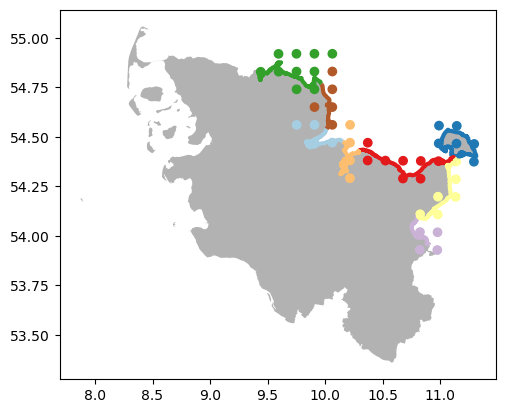

In [35]:
fig, ax = plt.subplots()
sh_border.plot(ax=ax, alpha=.6, color="gray")
sh_coast_split.plot(cmap="Paired", ax=ax, lw=3)
gdf_SH_release.plot(ax=ax, column="sh_coast", cmap="Paired",)
plt.show()

In [36]:
ds_SH = ds_trajectories.isel(trajectory=ds_trajectories.cell_ID.isin(gdf_SH_release.index).compute())
sh_coast_IDs = gdf_SH_release.loc[ds_SH.cell_ID,["sh_coast"]].to_numpy().T[0]
ds_SH = ds_SH.assign(dict(sh_coast=("trajectory", sh_coast_IDs))).sortby("sh_coast")

# Maps

In [37]:
ds_SH_lon = ds_SH.lon.compute()
ds_SH_lat = ds_SH.lat.compute()
sh_lon_min = np.floor(ds_SH_lon.min()).compute()
sh_lon_max = np.ceil(ds_SH_lon.max()).compute()
sh_lat_min = np.floor(ds_SH_lat.min()).compute()
sh_lat_max = np.ceil(ds_SH_lat.max()).compute()
sh_lon_range = sh_lon_max - sh_lon_min
sh_lat_range = sh_lat_max - sh_lat_min

In [85]:
bin_width = 1/8
ds_plot_count = ds_SH.groupby("subbasin").apply(
        lambda ds:
        calc_hist_0(
                ds.unstack(),
                np.arange(sh_lon_min, sh_lon_max + bin_width, bin_width),
                np.arange(sh_lat_min, sh_lat_max + bin_width, bin_width),
                dims=["trajectory"],
        )
).compute()

In [94]:
ds_plot_age = calc_hist_1(
        ds_SH,
        np.arange(sh_lon_min, sh_lon_max + bin_width, bin_width),
        np.arange(sh_lat_min, sh_lat_max + bin_width, bin_width),
        dims=["trajectory", "obs"],
        weights=ds_SH.obs,
).compute()

In [38]:
sh_central_longitude = np.mean((sh_lon_min, sh_lon_max))
map_projection = ccrs.EckertIV(central_longitude=sh_central_longitude)

In [39]:
extent_lon_min = sh_lon_min - sh_lon_range/20
extent_lon_max = sh_lon_max + sh_lon_range/20
extent_lat_min = sh_lat_min - sh_lat_range/50
extent_lat_max = sh_lat_max + sh_lat_range/50
sh_extent = (extent_lon_min, extent_lon_max, extent_lat_min, extent_lat_max)

## Heatmap

In [88]:
ds_plot_sum = ds_plot_count.sum(dim=("obs", "subbasin"))

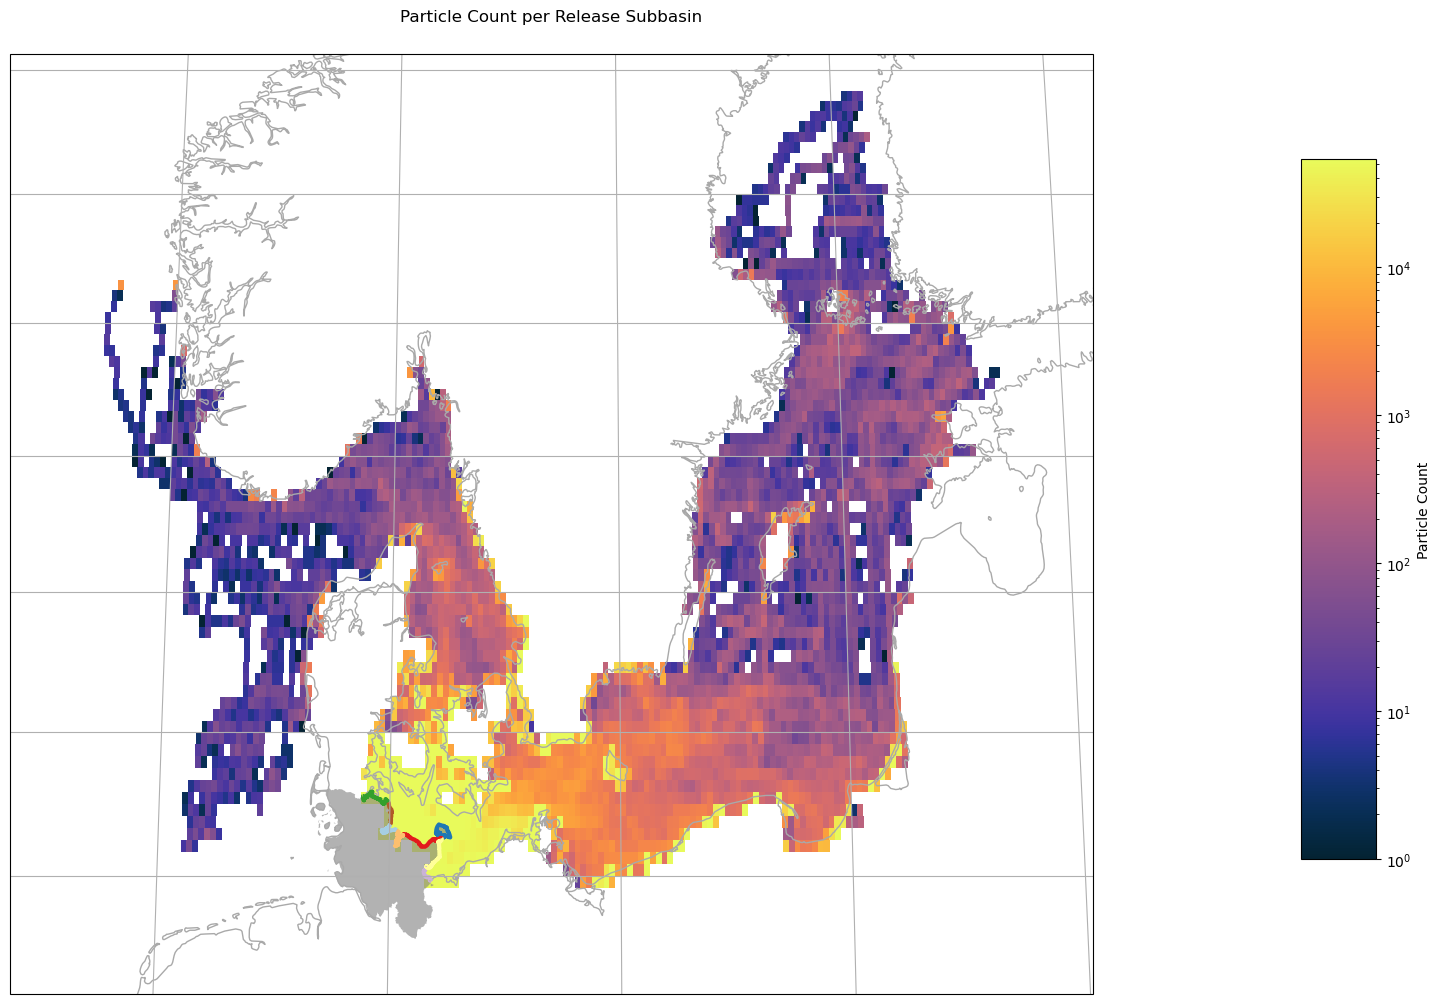

In [89]:
vmax = ds_plot_sum.where(ds_plot_sum.notnull() & ds_plot_sum > 0).quantile(0.95)
norm = LogNorm(vmin=1, vmax=vmax)
fig, ax = plt.subplots(
        figsize=(15, 10),
        sharex=True, 
        sharey=True, 
        subplot_kw=dict(projection=map_projection), 
)
fig.suptitle("Particle Count per Release Subbasin", y=1)
ax.set_extent(sh_extent, crs=PlateCarree())
im = ds_plot_sum.plot.pcolormesh(
        x="lon", 
        y="lat", 
        ax=ax, 
        norm=norm, 
        cmap=cmocean.cm.thermal,
        add_colorbar=False, 
        transform=PlateCarree(),
)
sh_border.plot(ax=ax, alpha=.6, color="gray", transform=Geodetic())
sh_coast_split.plot(ax=ax, cmap="Paired", lw=3, transform=Geodetic())
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=False)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Particle Count")
fig.tight_layout()
plt.show()

## Agemap

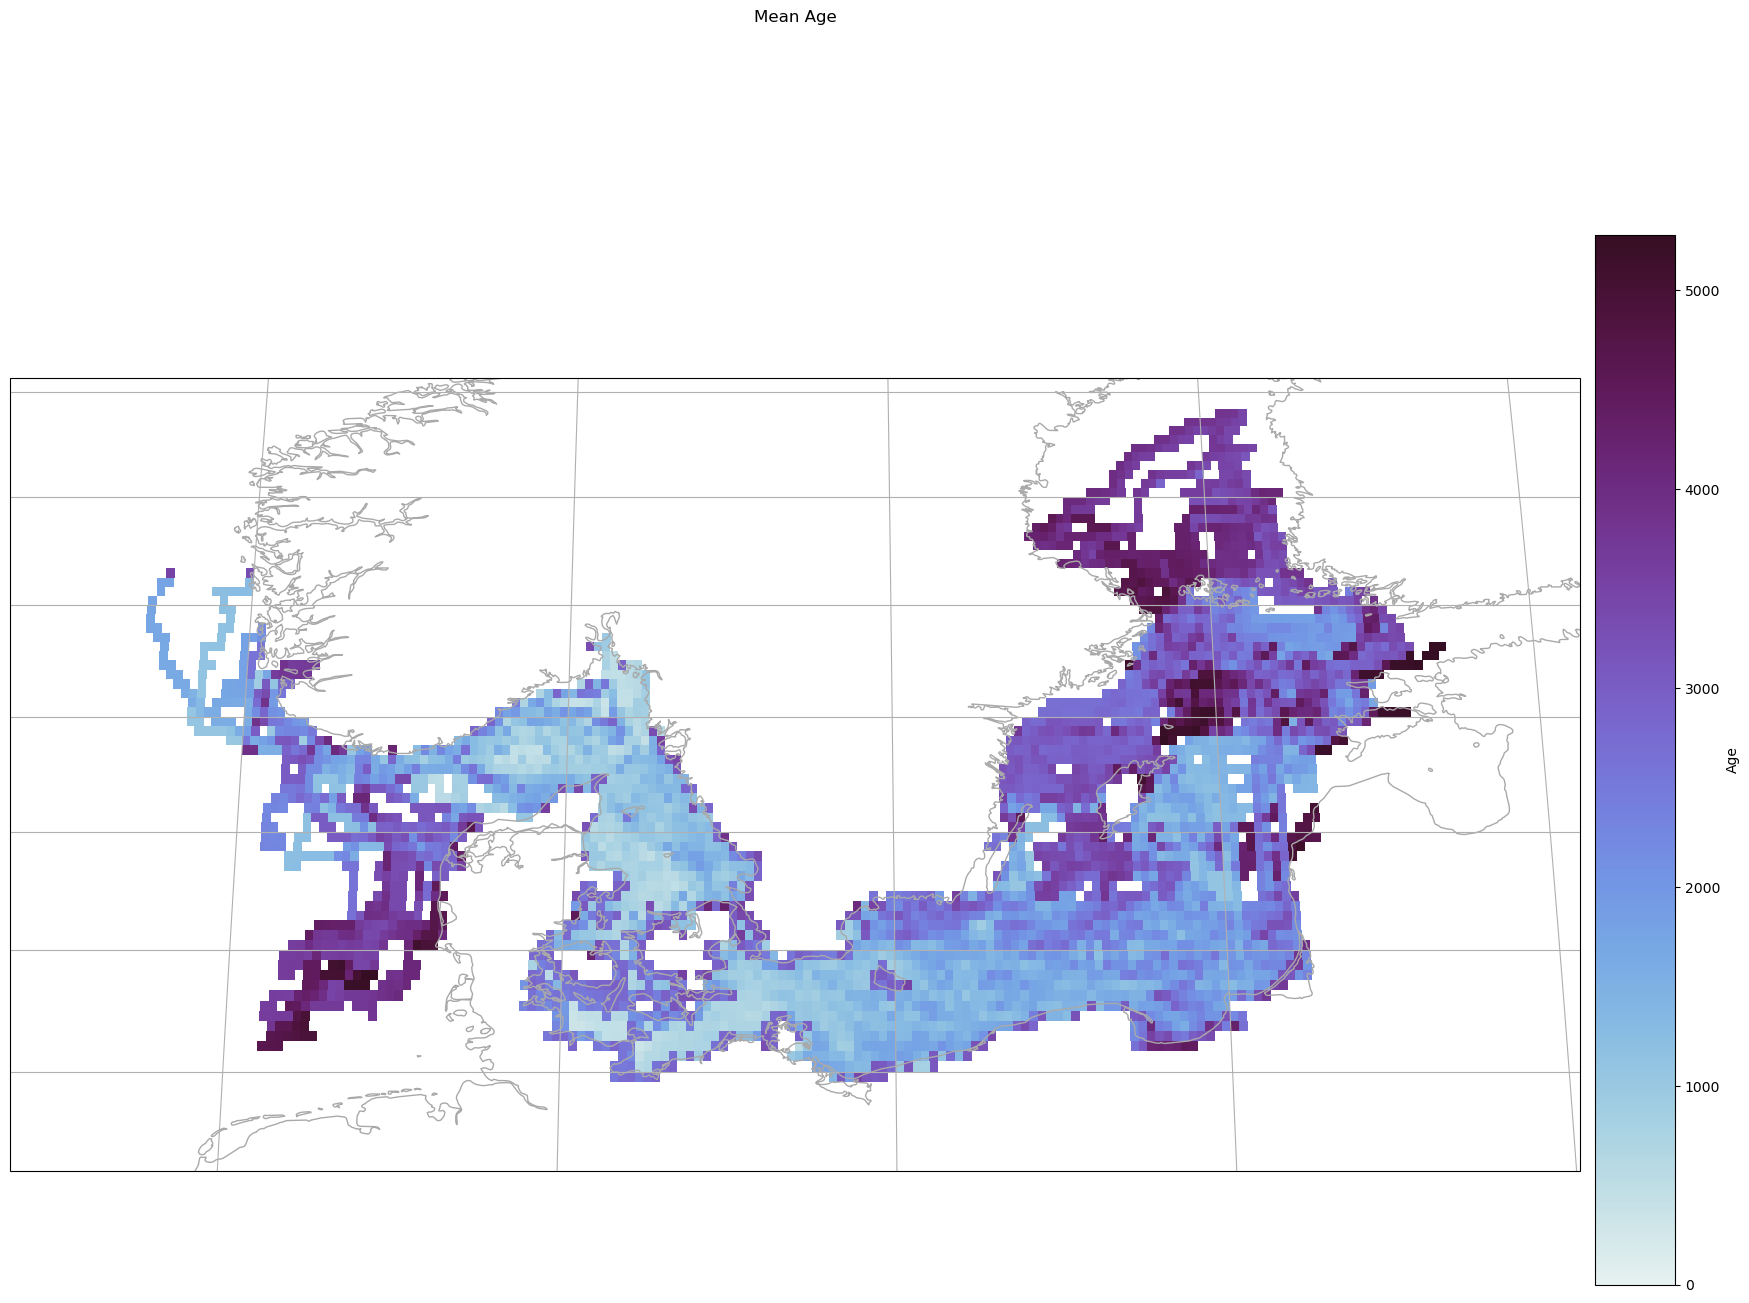

In [97]:
vmin = 0
vmax = 220*24
fig, ax = plt.subplots(
        figsize=(16, 15),
        subplot_kw=dict(projection=map_projection), 
)

fig.suptitle("Mean Age", y=1)
im = ds_plot_age.plot.pcolormesh(
        x="lon", 
        y="lat",
        ax=ax, 
        cmap=cmocean.cm.dense,
        vmin=vmin, 
        vmax=vmax, 
        add_colorbar=False, 
        transform=PlateCarree(),
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=False)
ax.set_extent(sh_extent, crs=PlateCarree())

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Age")
fig.tight_layout()
plt.show()

# Regional SH Plots

## Animations

In [44]:
end_point = 24*20
bins = np.arange(0, ds_SH.obs.max() , 8)
# bins = np.arange(0, end_point, 1)
ds_scatter_ani = ds_SH.groupby_bins(group="obs", bins=bins).mean(dim="obs", skipna=True).rename(dict(obs_bins="obs")).compute()

In [45]:
da_releasetime = ds_trajectories.time.isel(obs=0).sel(trajectory=ds_scatter_ani.trajectory).compute()
da_time = ds_trajectories.time.isel(obs=bins.astype(int), trajectory=0).compute()

In [ ]:
ds_scatter_ani = ds_scatter_ani.assign(
        dict(
                age = ("obs", (da_time - da_releasetime.isel(trajectory=0)).values[:-1]),
                release_time = ("trajectory", da_releasetime.values),
        )
)

ValueError: conflicting sizes for dimension 'obs': length 719 on 'age' and length 661 on {'obs': 'age_sec', 'trajectory': 'age_sec'}

In [47]:
ds_scatter_ani = ds_scatter_ani.where(ds_scatter_ani.age.notnull(), drop=True)

In [ ]:
colors = pd.factorize(ds_scatter_ani.isel(obs=0).sh_coast)
cmap = "rainbow"
fig, ax = plt.subplots(
        figsize=(15,15),
        subplot_kw=dict(projection=map_projection), 
)
ax.set_title(f"Ausbreitung über {ds_scatter_ani.age.max().dt.days.values} Tage")
scat = ax.scatter(
        ds_scatter_ani.isel(obs=0).lon,
        ds_scatter_ani.isel(obs=0).lat,
        c=colors[0], 
        label=colors[1],
        cmap=cmap, 
        s=3,
        transform=Geodetic(),
)
ax.add_feature(cartopy.feature.LAND, color="lightgrey")
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
ax.set_extent(sh_extent)

sh_border.plot(ax=ax, color="gray", edgecolor="darkgray", transform=Geodetic())
sh_coast_split.plot(ax=ax, cmap=cmap, lw=3, transform=Geodetic())

time_text = ax.text(0.7, 0.05, "Dauer: 0 Tage", transform=ax.transAxes, size=20)

def animate(frame):
        time_text.set_text("Dauer: " + str(ds_scatter_ani.age[frame].dt.days.values) + " Tage")
        ds = ds_scatter_ani.isel(obs=frame)
        scat.set_offsets(np.stack([ds.lon, ds.lat], axis=1))

ani = animation.FuncAnimation(fig, func=animate, interval=100, frames=len(ds_scatter_ani.obs)-1,)
# ani.save(filename=str(repo_path / "output/SH_scatter_surface_100.gif"), writer="pillow")
ani.save(filename=str(repo_path / f"output/SH_scatter_surface_100_d0-{ds_scatter_ani.age.max().dt.days.values}.mp4"), writer="ffmpeg")
plt.show()

In [40]:
bin_width = 1/8
ds_sh_coast_count = ds_SH.groupby("sh_coast").apply(
        lambda ds:
        calc_hist_0(
                ds.unstack(),
                np.arange(sh_lon_min, sh_lon_max + bin_width, bin_width),
                np.arange(sh_lat_min, sh_lat_max + bin_width, bin_width),
                dims=["trajectory", "obs"],
        )
).compute()

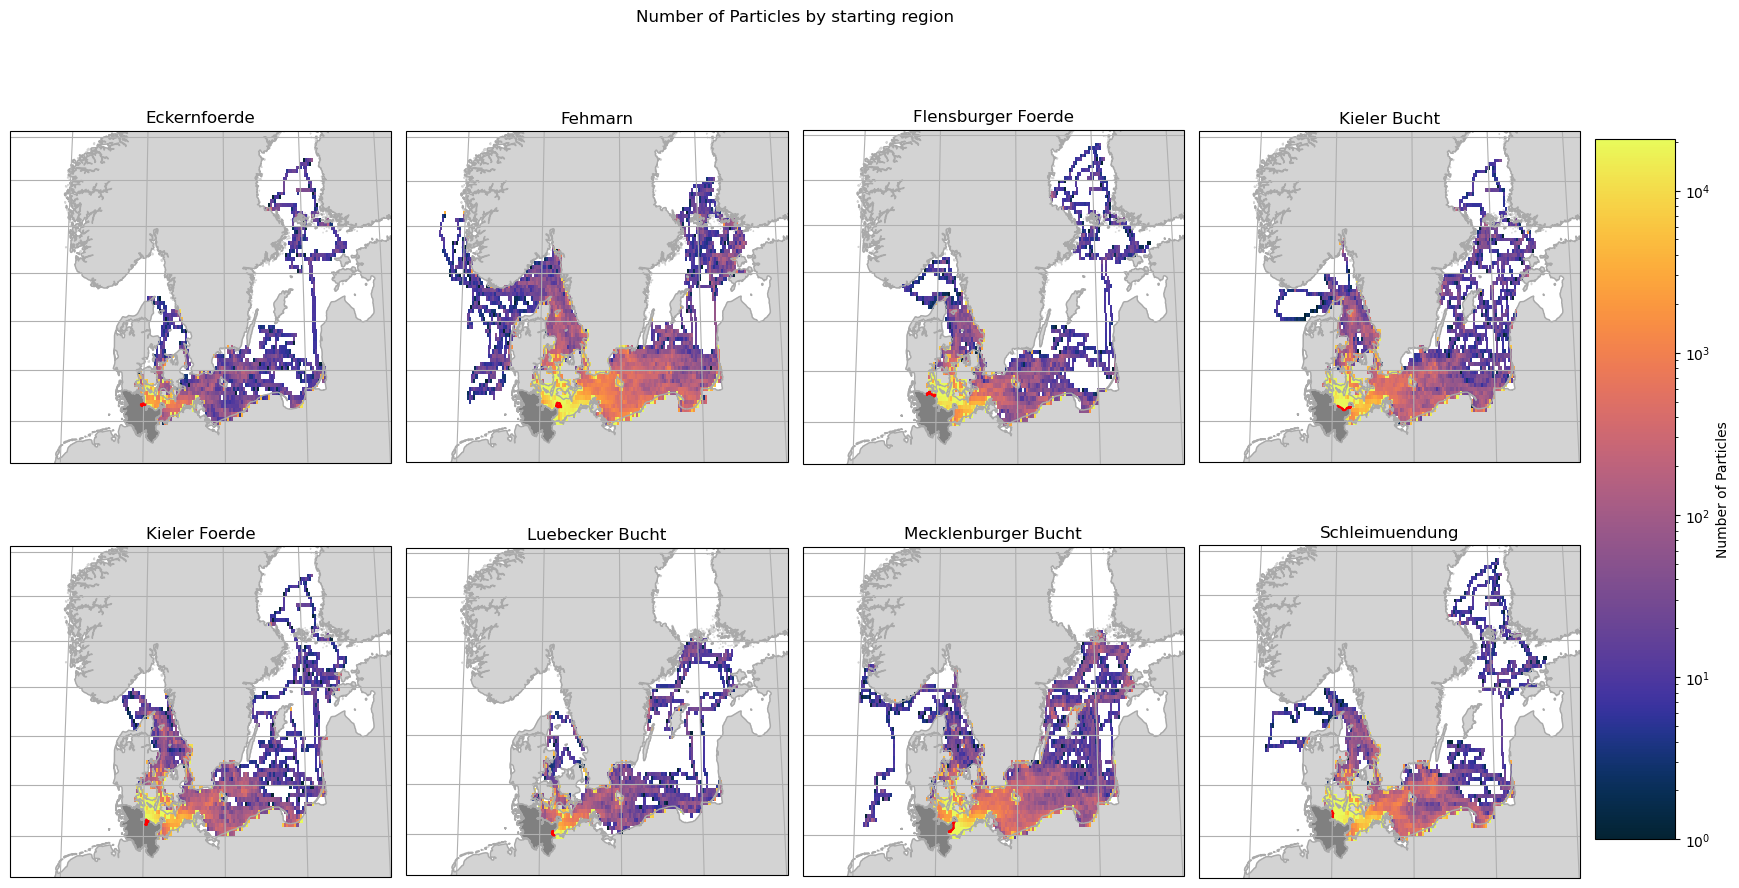

In [41]:
vmax = ds_sh_coast_count.where(ds_sh_coast_count.notnull() & ds_sh_coast_count > 0).quantile(0.95)
norm = LogNorm(vmin=1, vmax=vmax)
fig, axes = plt.subplots(
        figsize=(16, 10),
        nrows=2, 
        ncols=4, 
        sharex=True, 
        sharey=True, 
        subplot_kw=dict(projection=map_projection), 
)
fig.suptitle("Number of Particles by starting region")
for ax, coast_part in zip(axes.flatten(), ds_sh_coast_count.sh_coast.values):
        im = ds_sh_coast_count.sel(sh_coast=coast_part).plot.pcolormesh(
                x="lon", 
                y="lat", 
                ax=ax, 
                cmap=cmocean.cm.thermal,
                norm=norm, 
                add_colorbar=False, 
                transform=PlateCarree(),
        )
        ax.set_title(coast_part)
        ax.add_feature(cartopy.feature.LAND, color="lightgrey")
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent(sh_extent)
        sh_border.plot(ax=ax, color="gray", edgecolor="darkgray", transform=Geodetic())
        sh_coast_split.loc[[coast_part]].plot(ax=ax, lw=1.5, transform=Geodetic(), color="r")

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Number of Particles")
fig.tight_layout()
plt.show()

In [43]:
ds_month_count = ds_SH.groupby("release_time.month").apply(
        lambda ds:
        calc_hist_0(
                ds.unstack(),
                np.arange(sh_lon_min, sh_lon_max + bin_width, bin_width),
                np.arange(sh_lat_min, sh_lat_max + bin_width, bin_width),
                dims=["trajectory", "obs"],
        )
).compute()

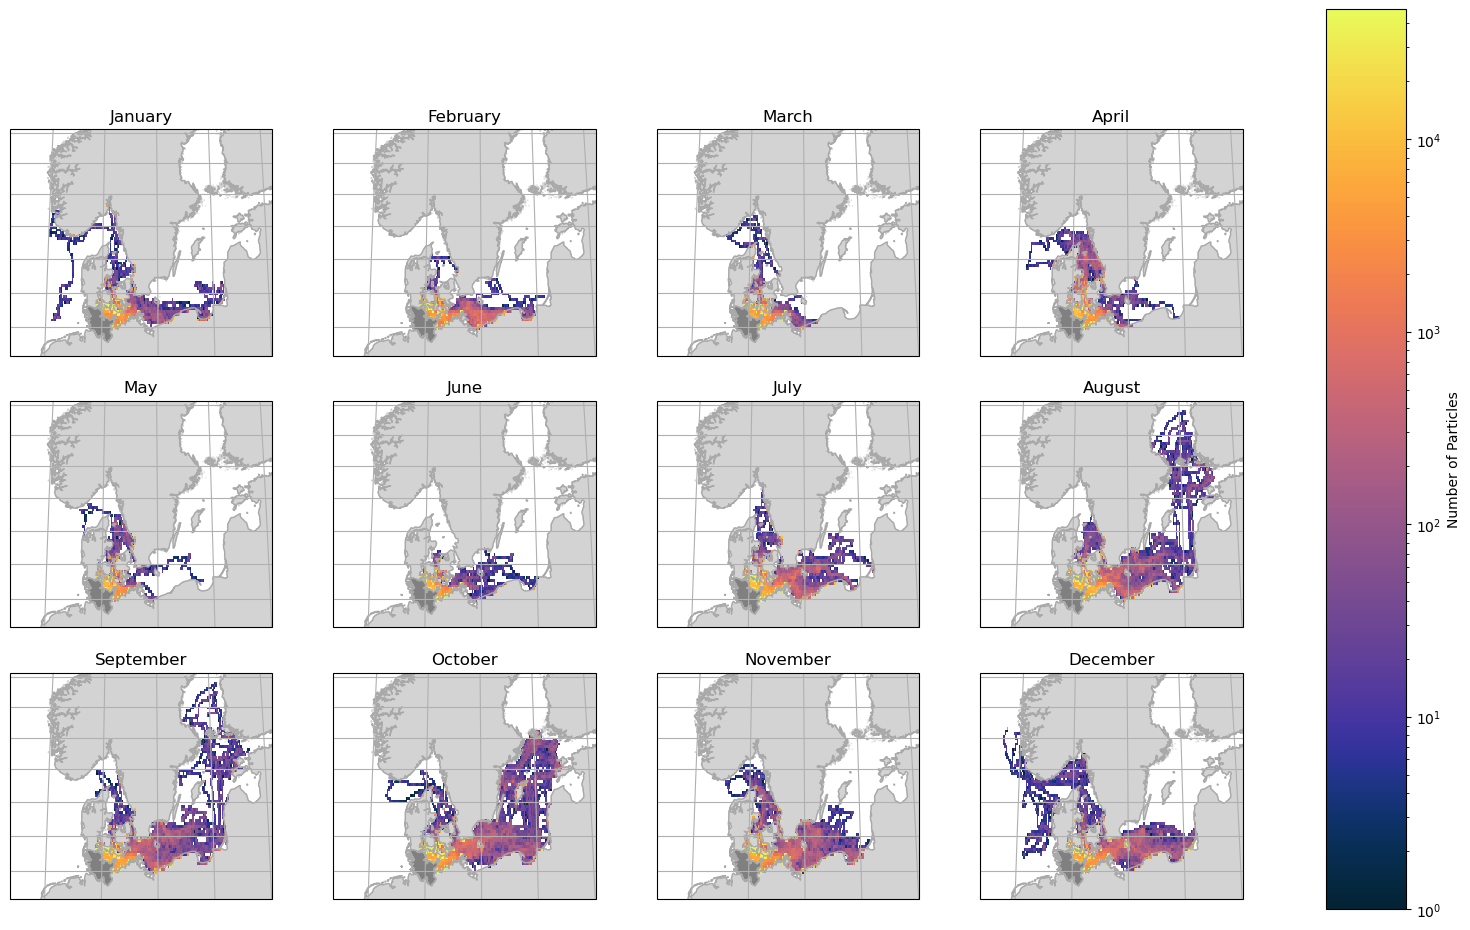

In [52]:
vmax = ds_month_count.where(ds_month_count.notnull() & ds_month_count>0).quantile(0.95)
norm = LogNorm(vmin=1, vmax=vmax)
fig, axes = plt.subplots(
        figsize=(16, 10),
        nrows=3, 
        ncols=4, 
        sharex=True, 
        sharey=True, 
        subplot_kw=dict(projection=map_projection), 
)
for ax, month in zip(axes.flatten(), ds_month_count):
        im = month.plot.pcolormesh(
                x="lon", 
                y="lat", 
                ax=ax, 
                cmap=cmocean.cm.thermal,
                norm=norm, 
                add_colorbar=False, 
                transform=PlateCarree(),
        )
        ax.set_title(datetime(year=2019, month=month.month.values, day=1).strftime("%B"))
        ax.add_feature(cartopy.feature.LAND, color="lightgrey")
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent(sh_extent)
        sh_border.plot(ax=ax, color="gray", edgecolor="darkgray", transform=Geodetic())

# fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([.95, 0.1, 0.05, 0.9])
fig.colorbar(im, cax=cbar_ax, label="Number of Particles")
# fig.tight_layout()
plt.show()

statistics of in which month and from which starting position do the particles travel how far, and the area

In [233]:
def calc_dist_quantiles(ds):
        dist = 111e3 * (
                ((ds[["lon", "lat"]] - ds.isel(obs=0, drop=True)[["lon", "lat"]]) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).quantile(np.linspace(0,1,5), dim="trajectory").rename("dist")

In [45]:
def calc_dist_mean(ds):
        dist = 111e3 * (
                ((ds[["lon", "lat"]] - ds.isel(obs=0, drop=True)[["lon", "lat"]]) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).mean(dim="trajectory").rename("dist")

In [ ]:
# df_distance_q = ds_trajectories.groupby("subbasin").apply(calc_dist_quantiles).compute().to_dataframe()
# df_distance_q.unstack(0).loc[0.5].assign(time=np.timedelta64(1, "h")*np.arange(5304)).set_index("time", drop=True).resample("5D").max()["dist"].plot()


In [55]:
df_distance_m = ds_SH[["lon", "lat", "sh_coast"]].groupby("sh_coast").apply(calc_dist_mean).to_dataframe()
df_distance_m = df_distance_m.unstack(0).assign(time=np.timedelta64(1, "h")*np.arange(len(ds_SH.obs))).set_index("time", drop=True).resample("5D").mean()["dist"]

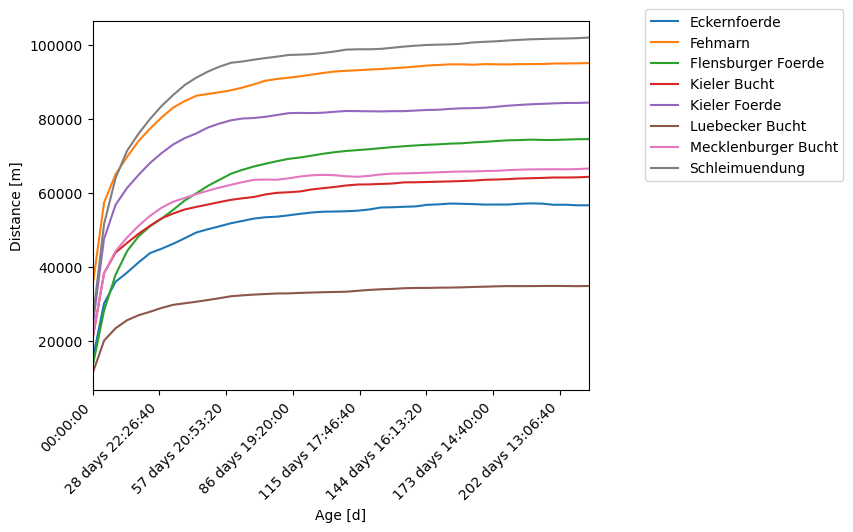

In [47]:
# fig, ax = plt.subplots(111, figsize=(15,10))
p = df_distance_m.plot()
p.legend(loc="best", bbox_to_anchor=(1.1, 1.05))
# p.tick_params("x", rotation=45,)
plt.xticks(rotation=45, ha="right")
# a =print(p.xaxis.get_ticklabels())
# print(p.xaxis.get_majorticklocs())
# p.xaxis.set_major_formatter()
# p.set_xticklabels(labels=np.timedelta64(1, "D")*np.arange(0, 220, 7))
p.set_xlabel("Age [d]")
p.set_ylabel("Distance [m]")
plt.show()

In [81]:
last_step_sh = last_step.sel(trajectory=ds_SH.trajectory)

In [82]:
last_step_sh = last_step_sh[["distance"]].to_dataframe().join(ds_SH.sh_coast.to_dataframe()).drop(columns="obs")

<Axes: xlabel='distance', ylabel='sh_coast'>

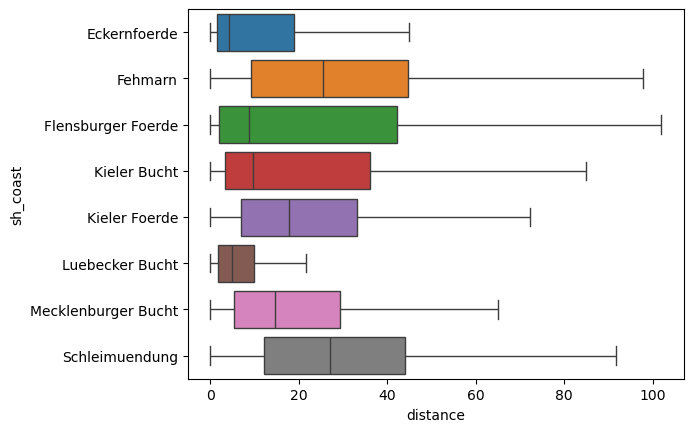

In [84]:
sns.boxplot(last_step_sh, x="distance", y="sh_coast", hue="sh_coast", showfliers=False)